<a href="https://colab.research.google.com/github/thaispaulino/b2b-revenue-intelligence/blob/notebooks%2Fgitkeep/nba_ltv_models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ── SETUP — Roda sempre que a sessão reiniciar ──────────────────────────
import os

os.chdir('/content')
!git clone https://github.com/thaispaulino/b2b-revenue-intelligence.git 2>/dev/null || echo "Already cloned"
os.chdir('/content/b2b-revenue-intelligence')
!mkdir -p data/raw data/processed models notebooks

# Fix paths
with open('src/generate_dataset.py', 'r') as f:
    content = f.read()
content = content.replace('"/home/claude/', '"data/raw/')
content = content.replace("'/home/claude/", "'data/raw/")
with open('src/generate_dataset.py', 'w') as f:
    f.write(content)

!python src/generate_dataset.py
print("✅ Setup complete — ready to run!")

Already cloned
Generating B2B CPaaS synthetic dataset...
  Accounts: 500 | Months: 12

[1/5] Account Managers...
      → 14 rows
[2/5] Accounts...
      → 500 rows
[3/5] Product Subscriptions...
      → 1257 rows
[4/5] Monthly Metrics...
      → 15084 rows
[5/5] Account Health (model input)...
      → 5000 rows

── Dataset Summary ──────────────────────────────────
Segments:   {'Mid-Market': 219, 'SMB': 151, 'Enterprise': 130}
Industries: {'Retail & E-commerce': 123, 'Fintech': 90, 'Logistics': 82, 'Healthcare': 74, 'Technology & SaaS': 73, 'Gaming & Entertainment': 58}
Churn rate: 11.8%
Products:   {'SMS': 410, 'Verification': 252, 'Voice': 241, 'Email': 187, 'WhatsApp Business': 167}
NBA labels: {'Nurture': 233, 'Retain': 118, 'Upsell': 90, 'Expand': 59}
Avg ARR:    SEK 1,024,577
Avg tenure: 22.5 months

✅ All tables saved to CSV.
✅ Setup complete — ready to run!


In [12]:
import os
os.chdir('/content')

# Clona o repo
!git clone https://github.com/thaispaulino/b2b-revenue-intelligence.git

# Entra na pasta
os.chdir('/content/b2b-revenue-intelligence')

# Cria pastas necessárias
!mkdir -p data/raw data/processed models notebooks

# Corrige e roda o generate_dataset
with open('src/generate_dataset.py', 'r') as f:
    content = f.read()
content = content.replace('"/home/claude/', '"data/raw/')
content = content.replace("'/home/claude/", "'data/raw/")
with open('src/generate_dataset.py', 'w') as f:
    f.write(content)

!python src/generate_dataset.py
!ls data/raw/

Cloning into 'b2b-revenue-intelligence'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 76 (delta 22), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 504.35 KiB | 2.56 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Generating B2B CPaaS synthetic dataset...
  Accounts: 500 | Months: 12

[1/5] Account Managers...
      → 14 rows
[2/5] Accounts...
      → 500 rows
[3/5] Product Subscriptions...
      → 1257 rows
[4/5] Monthly Metrics...
      → 15084 rows
[5/5] Account Health (model input)...
      → 5000 rows

── Dataset Summary ──────────────────────────────────
Segments:   {'Mid-Market': 219, 'SMB': 151, 'Enterprise': 130}
Industries: {'Retail & E-commerce': 123, 'Fintech': 90, 'Logistics': 82, 'Healthcare': 74, 'Technology & SaaS': 73, 'Gaming & Entertainment': 58}
Churn rate: 11.8%
Products:   {'SMS': 410, 'Verification': 252, 'Voice': 241, 'Email': 

Loading data...
  Accounts: 500 | Latest month: 2023-11
  NBA distribution: {'Nurture': 233, 'Retain': 118, 'Upsell': 90, 'Expand': 59}

  Features: 13
  Missing values: 0

  MODEL 1 — NBA CLASSIFIER (Random Forest)

  Train: 400 | Test: 100
  Class balance (train): {'Nurture': 187, 'Retain': 94, 'Upsell': 72, 'Expand': 47}

  Test Accuracy:          92.0%
  CV F1 (weighted):       0.919 ± 0.029

  Classification Report:
              precision    recall  f1-score   support

      Expand       0.86      1.00      0.92        12
     Nurture       0.95      0.87      0.91        46
      Retain       0.85      0.92      0.88        24
      Upsell       1.00      1.00      1.00        18

    accuracy                           0.92       100
   macro avg       0.91      0.95      0.93       100
weighted avg       0.92      0.92      0.92       100



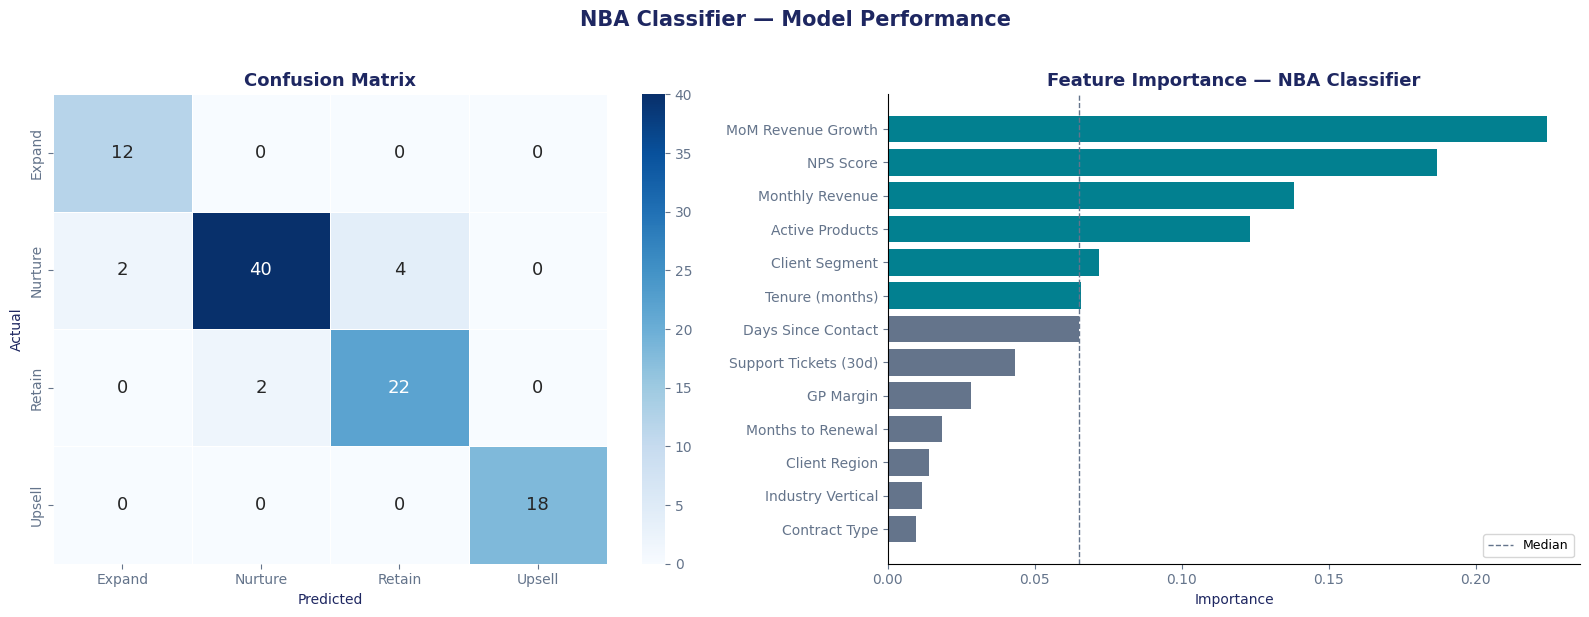

  TOP 3 FEATURES DRIVING NBA PREDICTIONS:
    MoM Revenue Growth             0.224
    NPS Score                      0.187
    Monthly Revenue                0.138

  MODEL 2 — LTV PREDICTOR (Gradient Boosting)

  Train: 400 | Test: 100
  LTV range: SEK 23,946 – 17,007,820
  LTV mean:  SEK 2,584,469

  MAE:   SEK 51,129
  MAPE:  1.9%
  R²:    0.999
  CV R²: 0.996 ± 0.002


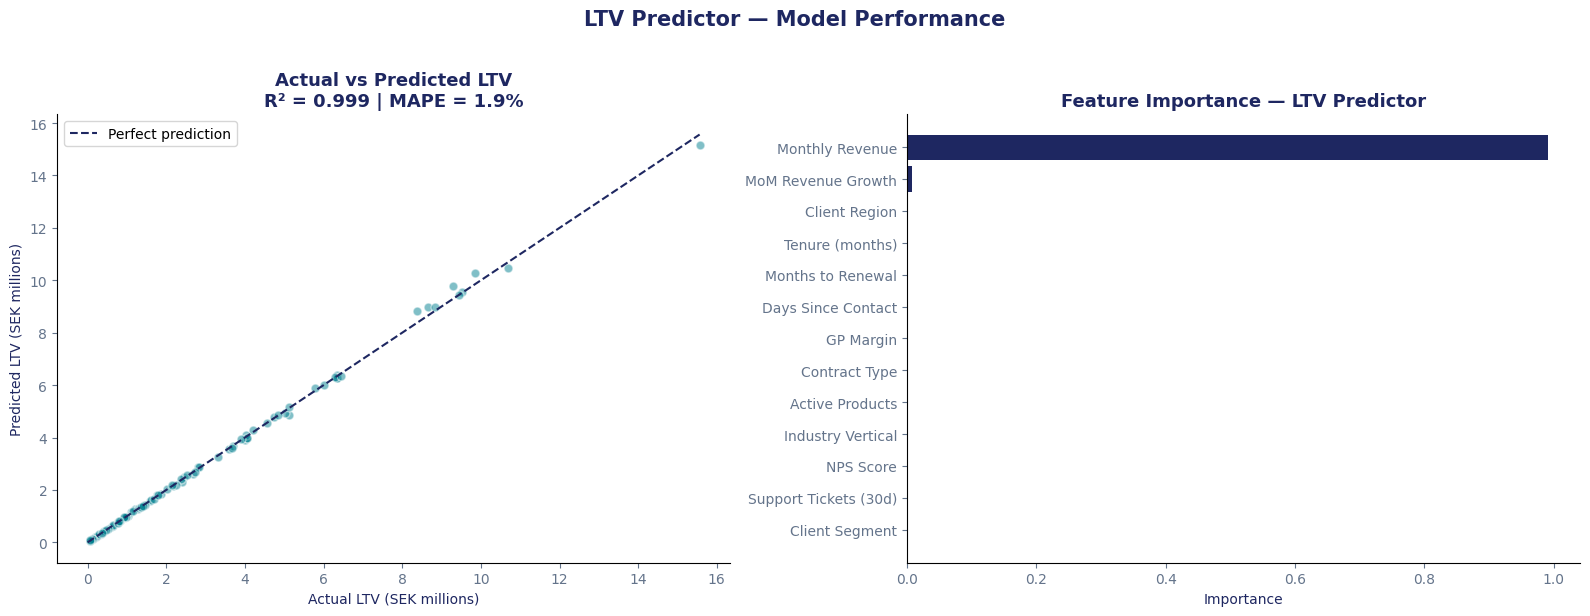


  TOP 3 FEATURES DRIVING LTV PREDICTIONS:
    Monthly Revenue                0.991
    MoM Revenue Growth             0.008
    Client Region                  0.000

  COMBINED OUTPUT — NBA + LTV per account

  Predictions generated: 500
  NBA accuracy (all):    98.4%
  Avg LTV predicted:     SEK 2,586,423

  TOP 10 PRIORITY ACCOUNTS:
client_id client_segment   industry_vertical nba_predicted  nba_confidence  ltv_predicted_sek  priority_score
  CLT0303     Enterprise           Logistics        Expand           0.915         16498187.0           0.933
  CLT0201     Enterprise             Fintech        Expand           0.926         15017644.0           0.901
  CLT0496     Enterprise Retail & E-commerce        Expand           0.894         15180644.0           0.893
  CLT0490     Enterprise             Fintech        Expand           0.886         15249452.0           0.892
  CLT0421     Enterprise          Healthcare        Expand           0.921         13070295.0           0.852
  

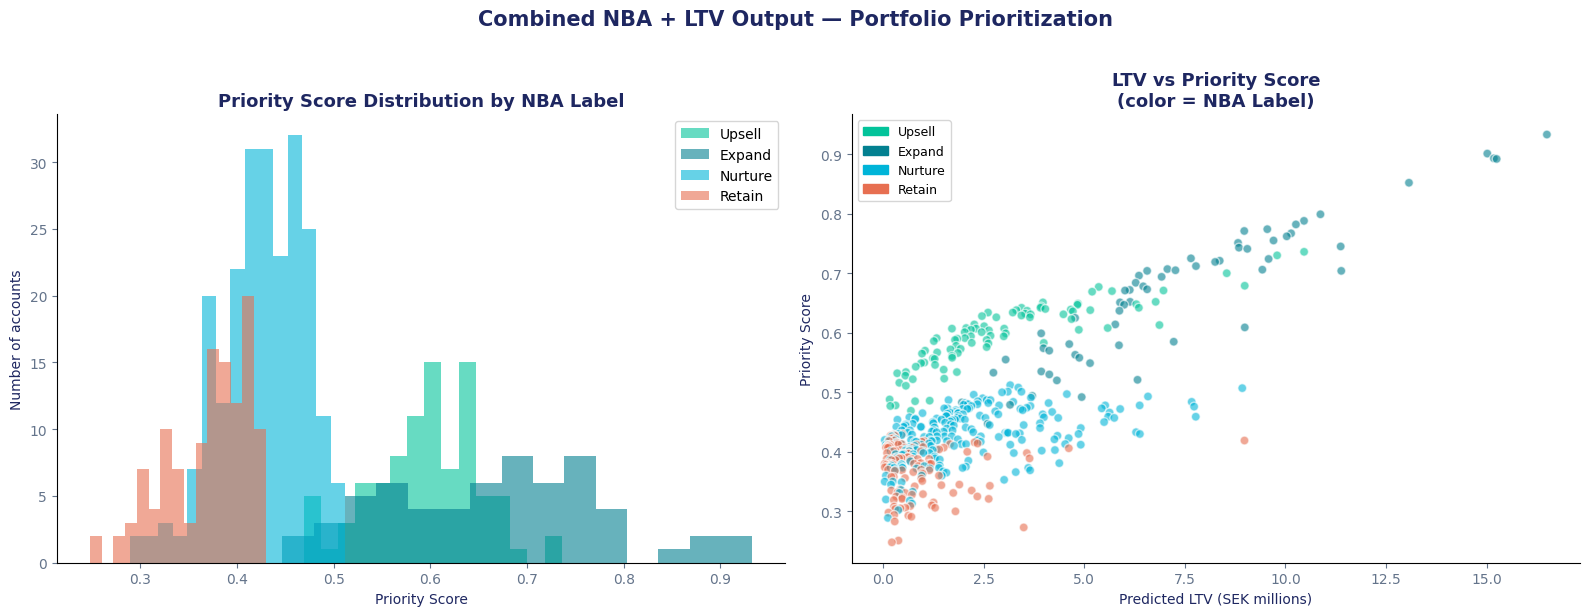


  EXPLAINABILITY — Permutation Importance
  (SHAP-equivalent: measures how much each feature
   affects predictions when randomly shuffled)


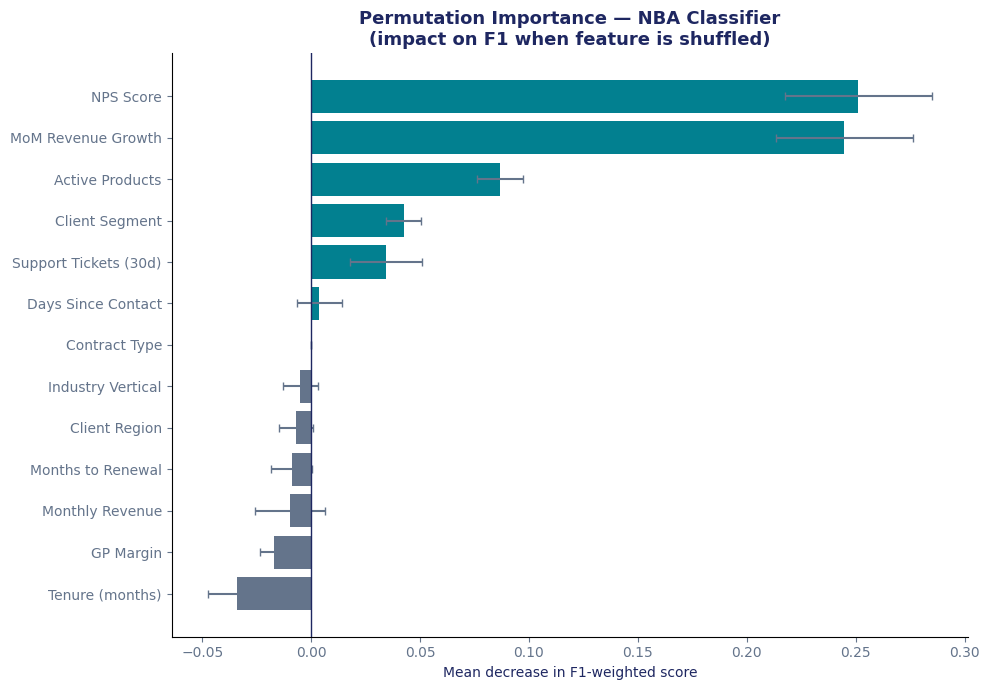


  TOP 5 MOST IMPORTANT FEATURES (NBA):
    ↑ NPS Score                      +0.2513 ± 0.0337
    ↑ MoM Revenue Growth             +0.2448 ± 0.0315
    ↑ Active Products                +0.0869 ± 0.0106
    ↑ Client Segment                 +0.0425 ± 0.0080
    ↑ Support Tickets (30d)          +0.0343 ± 0.0165

  Models saved to models/

  DEMO — PREDICTION FOR A SINGLE ACCOUNT

  Account:        TechLabs AS
  Segment:        Enterprise
  Industry:       Logistics
  Region:         LATAM

  ─── MODEL OUTPUT ───────────────────────────────────
  NBA Action:     Expand (confidence: 92%)
  LTV 12m:        SEK 16,498,187
  Priority Score: 0.933
  ────────────────────────────────────────────────────

  What this means for the AM:
  → Action "Expand" with 92% confidence
  → Estimated value of SEK 16.5M over next 12 months
  → Priority rank: #1 in portfolio

  WEEK 4 — NBA + LTV MODELS COMPLETE

🎯 NBA CLASSIFIER (Random Forest)
   CV F1 (weighted): 0.919 ± 0.029
   Class imbalance handled via c

In [13]:
"""
B2B Revenue Intelligence — NBA Classifier + LTV Predictor
Week 4: Classification + Regression + Feature Importance

Models:
    1. NBA Classifier (Random Forest) — Upsell / Expand / Retain / Nurture
    2. LTV Predictor (Gradient Boosting) — 12-month revenue estimate
    Both include feature importance for explainability (SHAP-equivalent)

HOW TO USE IN COLAB:
    exec(open('notebooks/03_nba_ltv_models.py').read())

OUTPUT:
    data/processed/nba_predictions.csv
    data/processed/ltv_predictions.csv
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              mean_absolute_error, mean_absolute_percentage_error, r2_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance

# ── Style ──────────────────────────────────────────────────────────────────
NAVY    = '#1E2761'
TEAL    = '#028090'
MINT    = '#02C39A'
ACCENT  = '#00B4D8'
GRAY    = '#64748B'
PALETTE = [NAVY, TEAL, MINT, ACCENT, '#F4A261', '#E76F51']
NBA_COLORS = {'Upsell': MINT, 'Expand': TEAL, 'Nurture': ACCENT, 'Retain': '#E76F51'}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False,    'axes.spines.right': False,
    'axes.labelcolor': NAVY,     'axes.titlecolor': NAVY,
    'axes.titlesize': 13,        'axes.titleweight': 'bold',
    'font.family': 'sans-serif', 'xtick.color': GRAY, 'ytick.color': GRAY,
})

DATA_PATH = 'data/raw'
OUT_PATH  = 'data/processed'
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs('models', exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────
print("Loading data...")
health = pd.read_csv(f'{DATA_PATH}/account_health.csv')
acc    = pd.read_csv(f'{DATA_PATH}/accounts.csv')

# Use latest month snapshot
latest = health[health['month'] == health['month'].max()].copy()
print(f"  Accounts: {len(latest):,} | Latest month: {health['month'].max()}")
print(f"  NBA distribution: {latest['nba_label'].value_counts().to_dict()}")
print()

# ── Feature Engineering ───────────────────────────────────────────────────
le = LabelEncoder()

# Encode categoricals
for col in ['client_segment', 'client_region', 'industry_vertical', 'contract_type']:
    latest[f'{col}_enc'] = le.fit_transform(latest[col])

# Feature set — same for both models
FEATURES = [
    'tenure_months',
    'active_products_count',
    'total_revenue_sek',
    'mom_revenue_growth',
    'nps_score_proxy',
    'support_tickets_30d',
    'days_since_last_contact',
    'months_to_renewal',
    'gp_margin',
    'client_segment_enc',
    'industry_vertical_enc',
    'client_region_enc',
    'contract_type_enc',
]

FEATURE_LABELS = [
    'Tenure (months)',
    'Active Products',
    'Monthly Revenue',
    'MoM Revenue Growth',
    'NPS Score',
    'Support Tickets (30d)',
    'Days Since Contact',
    'Months to Renewal',
    'GP Margin',
    'Client Segment',
    'Industry Vertical',
    'Client Region',
    'Contract Type',
]

X = latest[FEATURES].copy()
print(f"  Features: {len(FEATURES)}")
print(f"  Missing values: {X.isnull().sum().sum()}")
print()


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — NBA CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  MODEL 1 — NBA CLASSIFIER (Random Forest)")
print("=" * 60)

y_nba = latest['nba_label']
NBA_CLASSES = ['Expand', 'Nurture', 'Retain', 'Upsell']

# Train / test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y_nba, test_size=0.20, random_state=42, stratify=y_nba
)
print(f"\n  Train: {len(X_train)} | Test: {len(X_test)}")
print(f"  Class balance (train): {y_train.value_counts().to_dict()}")

# ── Train model ───────────────────────────────────────────────────────────
nba_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
nba_model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred_nba = nba_model.predict(X_test)
y_prob_nba = nba_model.predict_proba(X_test)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(nba_model, X, y_nba, cv=cv, scoring='f1_weighted')

print(f"\n  Test Accuracy:          {(y_pred_nba == y_test).mean():.1%}")
print(f"  CV F1 (weighted):       {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print("  Classification Report:")
print(classification_report(y_test, y_pred_nba, target_names=sorted(y_nba.unique())))

# ── Visualize: Confusion Matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NBA Classifier — Model Performance', fontsize=15, fontweight='bold', color=NAVY, y=1.02)

cm = confusion_matrix(y_test, y_pred_nba, labels=sorted(y_nba.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_nba.unique()),
            yticklabels=sorted(y_nba.unique()),
            ax=axes[0], linewidths=0.5, annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance
importances = nba_model.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURE_LABELS, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

axes[1].barh(fi_df['feature'], fi_df['importance'],
             color=[TEAL if v > fi_df['importance'].median() else GRAY
                    for v in fi_df['importance']])
axes[1].set_title('Feature Importance — NBA Classifier')
axes[1].set_xlabel('Importance')
axes[1].axvline(fi_df['importance'].median(), color=GRAY, linestyle='--',
                linewidth=1, label='Median')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/12_nba_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature importance insights ───────────────────────────────────────────
top3 = fi_df.sort_values('importance', ascending=False).head(3)
print("  TOP 3 FEATURES DRIVING NBA PREDICTIONS:")
for _, row in top3.iterrows():
    print(f"    {row['feature']:30s} {row['importance']:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — LTV PREDICTOR
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  MODEL 2 — LTV PREDICTOR (Gradient Boosting)")
print("=" * 60)

y_ltv = latest['ltv_12m_estimate_sek']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X, y_ltv, test_size=0.20, random_state=42
)
print(f"\n  Train: {len(X_train_l)} | Test: {len(X_test_l)}")
print(f"  LTV range: SEK {y_ltv.min():,.0f} – {y_ltv.max():,.0f}")
print(f"  LTV mean:  SEK {y_ltv.mean():,.0f}")

# ── Train model ───────────────────────────────────────────────────────────
ltv_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
ltv_model.fit(X_train_l, y_train_l)

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred_ltv = ltv_model.predict(X_test_l)

mae   = mean_absolute_error(y_test_l, y_pred_ltv)
mape  = mean_absolute_percentage_error(y_test_l, y_pred_ltv)
r2    = r2_score(y_test_l, y_pred_ltv)
cv_r2 = cross_val_score(ltv_model, X, y_ltv, cv=5, scoring='r2')

print(f"\n  MAE:   SEK {mae:,.0f}")
print(f"  MAPE:  {mape:.1%}")
print(f"  R²:    {r2:.3f}")
print(f"  CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# ── Visualize: Actual vs Predicted ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LTV Predictor — Model Performance', fontsize=15, fontweight='bold', color=NAVY, y=1.02)

axes[0].scatter(y_test_l/1e6, y_pred_ltv/1e6, alpha=0.5, color=TEAL, s=40, edgecolors='white')
max_val = max(y_test_l.max(), y_pred_ltv.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], color=NAVY, linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual LTV (SEK millions)')
axes[0].set_ylabel('Predicted LTV (SEK millions)')
axes[0].set_title(f'Actual vs Predicted LTV\nR² = {r2:.3f} | MAPE = {mape:.1%}')
axes[0].legend()

# Feature importance
ltv_fi = pd.DataFrame({'feature': FEATURE_LABELS,
                        'importance': ltv_model.feature_importances_})
ltv_fi = ltv_fi.sort_values('importance', ascending=True)

axes[1].barh(ltv_fi['feature'], ltv_fi['importance'],
             color=[NAVY if v > ltv_fi['importance'].median() else GRAY
                    for v in ltv_fi['importance']])
axes[1].set_title('Feature Importance — LTV Predictor')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/13_ltv_performance.png', dpi=150, bbox_inches='tight')
plt.show()

top3_ltv = ltv_fi.sort_values('importance', ascending=False).head(3)
print("\n  TOP 3 FEATURES DRIVING LTV PREDICTIONS:")
for _, row in top3_ltv.iterrows():
    print(f"    {row['feature']:30s} {row['importance']:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# COMBINE: NBA + LTV PREDICTIONS PER ACCOUNT
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  COMBINED OUTPUT — NBA + LTV per account")
print("=" * 60)

# Predict on ALL accounts
nba_predictions  = nba_model.predict(X)
nba_probabilities = nba_model.predict_proba(X)
ltv_predictions  = ltv_model.predict(X)

# Build output dataframe
output_df = latest[['client_id', 'client_segment', 'industry_vertical',
                     'client_region', 'nba_label', 'ltv_12m_estimate_sek']].copy()
output_df['nba_predicted']        = nba_predictions
output_df['nba_confidence']       = nba_probabilities.max(axis=1).round(3)
output_df['ltv_predicted_sek']    = ltv_predictions.round(0)
output_df['ltv_actual_sek']       = latest['ltv_12m_estimate_sek']
output_df['nba_correct']          = (output_df['nba_predicted'] == output_df['nba_label'])

# Priority score: high LTV + high confidence + Upsell/Expand label
def priority_score(row):
    action_weight = {'Upsell': 1.0, 'Expand': 0.85, 'Nurture': 0.5, 'Retain': 0.3}
    ltv_norm = min(row['ltv_predicted_sek'] / output_df['ltv_predicted_sek'].max(), 1.0)
    return round(
        0.40 * ltv_norm +
        0.35 * row['nba_confidence'] +
        0.25 * action_weight.get(row['nba_predicted'], 0.5),
        3
    )

output_df['priority_score'] = output_df.apply(priority_score, axis=1)
output_df = output_df.sort_values('priority_score', ascending=False)
output_df.to_csv(f'{OUT_PATH}/nba_ltv_predictions.csv', index=False)

print(f"\n  Predictions generated: {len(output_df):,}")
print(f"  NBA accuracy (all):    {output_df['nba_correct'].mean():.1%}")
print(f"  Avg LTV predicted:     SEK {output_df['ltv_predicted_sek'].mean():,.0f}")
print()
print("  TOP 10 PRIORITY ACCOUNTS:")
top10 = output_df.head(10)[['client_id','client_segment','industry_vertical',
                              'nba_predicted','nba_confidence','ltv_predicted_sek','priority_score']]
print(top10.to_string(index=False))


# ── Visualize Combined Output ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Combined NBA + LTV Output — Portfolio Prioritization',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Priority score distribution by NBA label
for label in ['Upsell', 'Expand', 'Nurture', 'Retain']:
    subset = output_df[output_df['nba_predicted'] == label]['priority_score']
    axes[0].hist(subset, bins=15, alpha=0.6, label=label, color=NBA_COLORS[label])
axes[0].set_title('Priority Score Distribution by NBA Label')
axes[0].set_xlabel('Priority Score')
axes[0].set_ylabel('Number of accounts')
axes[0].legend()

# LTV vs Priority Score scatter
scatter_colors = [NBA_COLORS[l] for l in output_df['nba_predicted']]
axes[1].scatter(output_df['ltv_predicted_sek']/1e6,
                output_df['priority_score'],
                c=scatter_colors, alpha=0.6, s=40, edgecolors='white')
axes[1].set_xlabel('Predicted LTV (SEK millions)')
axes[1].set_ylabel('Priority Score')
axes[1].set_title('LTV vs Priority Score\n(color = NBA Label)')
patches = [mpatches.Patch(color=NBA_COLORS[l], label=l) for l in NBA_COLORS]
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/14_combined_output.png', dpi=150, bbox_inches='tight')
plt.show()


# ── SHAP-style: Permutation Importance ────────────────────────────────────
print()
print("=" * 60)
print("  EXPLAINABILITY — Permutation Importance")
print("=" * 60)
print("  (SHAP-equivalent: measures how much each feature")
print("   affects predictions when randomly shuffled)")

perm_imp = permutation_importance(nba_model, X_test, y_test,
                                   n_repeats=10, random_state=42,
                                   scoring='f1_weighted')
perm_df = pd.DataFrame({
    'feature':    FEATURE_LABELS,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [TEAL if v > 0 else GRAY for v in perm_df['importance']]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors,
        error_kw={'ecolor': GRAY, 'capsize': 3})
ax.axvline(0, color=NAVY, linewidth=1)
ax.set_title('Permutation Importance — NBA Classifier\n(impact on F1 when feature is shuffled)',
             fontweight='bold', color=NAVY)
ax.set_xlabel('Mean decrease in F1-weighted score')
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/15_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("  TOP 5 MOST IMPORTANT FEATURES (NBA):")
top5_perm = perm_df.sort_values('importance', ascending=False).head(5)
for _, row in top5_perm.iterrows():
    direction = "↑" if row['importance'] > 0 else "↓"
    print(f"    {direction} {row['feature']:30s} {row['importance']:+.4f} ± {row['std']:.4f}")


# ── Save models ───────────────────────────────────────────────────────────
joblib.dump(nba_model, 'models/nba_classifier.pkl')
joblib.dump(ltv_model, 'models/ltv_predictor.pkl')
print(f"\n  Models saved to models/")


# ─────────────────────────────────────────────────────────────────────────────
# DEMO — SINGLE ACCOUNT PREDICTION
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  DEMO — PREDICTION FOR A SINGLE ACCOUNT")
print("=" * 60)

demo = output_df.iloc[0]  # top priority account
demo_features = X.loc[latest[latest['client_id'] == demo['client_id']].index]
demo_acc = acc[acc['client_id'] == demo['client_id']].iloc[0]

print(f"""
  Account:        {demo_acc['client_name']}
  Segment:        {demo['client_segment']}
  Industry:       {demo['industry_vertical']}
  Region:         {demo['client_region']}

  ─── MODEL OUTPUT ───────────────────────────────────
  NBA Action:     {demo['nba_predicted']} (confidence: {demo['nba_confidence']:.0%})
  LTV 12m:        SEK {demo['ltv_predicted_sek']:,.0f}
  Priority Score: {demo['priority_score']:.3f}
  ────────────────────────────────────────────────────

  What this means for the AM:
  → Action "{demo['nba_predicted']}" with {demo['nba_confidence']:.0%} confidence
  → Estimated value of SEK {demo['ltv_predicted_sek']/1e6:.1f}M over next 12 months
  → Priority rank: #1 in portfolio
""")


# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  WEEK 4 — NBA + LTV MODELS COMPLETE")
print("=" * 60)
print(f"""
🎯 NBA CLASSIFIER (Random Forest)
   CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}
   Class imbalance handled via class_weight='balanced'
   Top driver: {top3.iloc[0]['feature']}

💰 LTV PREDICTOR (Gradient Boosting)
   R²:   {r2:.3f}
   MAPE: {mape:.1%}
   MAE:  SEK {mae:,.0f}
   Top driver: {top3_ltv.iloc[0]['feature']}

📊 COMBINED OUTPUT
   {len(output_df):,} accounts scored with NBA + LTV + Priority
   Top priority: {demo['client_segment']} | {demo['industry_vertical']} | {demo['nba_predicted']}

📁 FILES SAVED
   nba_ltv_predictions.csv  → input for pipeline (Week 5)
   models/nba_classifier.pkl
   models/ltv_predictor.pkl
""")
print("  NBA + LTV Models ✅ — Next: 04_pipeline.py")
print("=" * 60)